# Module 3b — open temporal instrument: `R_δ(N, γ_φ t)` curves

Reproducible example for `tmc_numerics.modules.open_instrument`. Regenerates the committed result `results/open_instrument_redundancy_v0.1.json` from scratch. The candidate worked exemplar for **Anti-Claim #6**, within the assumed-einselection regime.

> **Einselection caveat (verbatim).** Module 3b computes `R_δ(N, γ_φ, t)` *conditional on the assumption that the temporal pointer `T` is einselected* (MN v0.2 §1.1). The existence of a dynamically-derived temporal-pointer basis — the temporal analogue of environment-induced superselection — is the hardest part of the Coastline's principal open problem (**Anti-Claim #6**) and is **not** addressed here: it is *assumed*, not derived. Module 3b is therefore a **candidate** worked exemplar of a *redundant temporal record* **within the assumed regime**, not a resolution of Anti-Claim #6, which **remains open**. Whether any such instance counts as *the* worked exemplar that converts Coastline Claim II from analogy to demonstration is a Coastline-level judgement reserved to the steward (Lock-Key).

In [1]:
%matplotlib inline
import json
import numpy as np
import matplotlib.pyplot as plt
import tmc_numerics as tn
from tmc_numerics.modules.open_instrument import (
    OpenInstrumentParams, single_carrier_coherence, carrier_distinguishability,
    redundancy_at, redundancy_curve)
print('tmc_numerics', tn.__version__)

tmc_numerics 0.1.0.dev0


## 1. Derive `ε` from a single-carrier dephasing master equation

`c = 2|ρ₀₁|` of `|+⟩` evolved under `(γ_φ/2)D[σ_z]` (Phase-1 `evolve`) `= e^{−γ_φ t}`; then `ε = (1−c)/2` (trace-distance / Helstrom / phase-bin projective — all coincide).

In [2]:
gamma_phi = 1.0
for t in [0.0, 0.25, np.log(5/3), 1.0, 2.0]:
    c = single_carrier_coherence(gamma_phi, t)
    eps = carrier_distinguishability(gamma_phi, t)
    print(f'gamma_phi*t={t:<7.4f} c={c:.4f}  eps=(1-c)/2={eps:.4f}  [analytic {(1-np.exp(-t))/2:.4f}]')

gamma_phi*t=0.0000  c=1.0000  eps=(1-c)/2=0.0000  [analytic 0.0000]
gamma_phi*t=0.2500  c=0.7788  eps=(1-c)/2=0.1106  [analytic 0.1106]
gamma_phi*t=0.5108  c=0.6000  eps=(1-c)/2=0.2000  [analytic 0.2000]
gamma_phi*t=1.0000  c=0.3679  eps=(1-c)/2=0.3161  [analytic 0.3161]
gamma_phi*t=2.0000  c=0.1353  eps=(1-c)/2=0.4323  [analytic 0.4323]


## 2. D5 cross-link — the dynamical path lands on the MN §2 analytic pole

At `γ_φ t = ln(5/3)` (`ε=0.20`), `R_{0.10}(N=64)` must equal `64/9` exactly.

In [3]:
t_star = np.log(5/3)
r = redundancy_at(OpenInstrumentParams(gamma_phi, t_star, 64, 0.10))
print(f'gamma_phi*t = ln(5/3) = {t_star:.4f}  ->  eps = 0.20')
print(f'R_0.10(N=64) = {r.R_delta:.6f}  (64/9 = {64/9:.6f}),  m_delta = {r.m_delta}')
assert abs(r.R_delta - 64/9) < 1e-9 and r.m_delta == 9
print('OK - dynamical path reproduces the analytic pole to the D5 standard')

gamma_phi*t = ln(5/3) = 0.5108  ->  eps = 0.20
R_0.10(N=64) = 7.111111  (64/9 = 7.111111),  m_delta = 9
OK - dynamical path reproduces the analytic pole to the D5 standard


## 3. `R_δ(N, γ_φ t)` curves

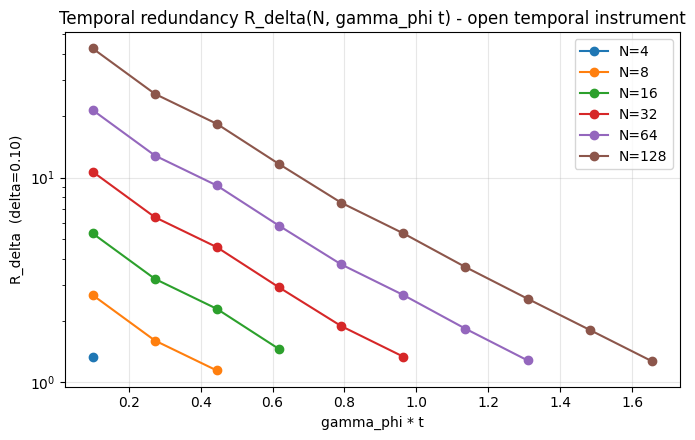

In [4]:
n_values = [4, 8, 16, 32, 64, 128]
t_values = [round(x, 3) for x in np.linspace(0.1, 2.0, 12)]
cur = redundancy_curve(gamma_phi=gamma_phi, t_values=t_values, n_values=n_values, deficit=0.10)
plt.figure(figsize=(7, 4.5))
for n in n_values:
    pts = [(row[0], row[2]) for row in cur['grid'][n] if row[2] is not None]
    if pts:
        xs, ys = zip(*pts)
        plt.plot(xs, ys, 'o-', label=f'N={n}')
plt.xlabel('gamma_phi * t'); plt.ylabel('R_delta  (delta=0.10)'); plt.yscale('log')
plt.title('Temporal redundancy R_delta(N, gamma_phi t) - open temporal instrument')
plt.legend(); plt.grid(True, alpha=0.3); plt.tight_layout(); plt.show()

## 4. The undefined boundary rises with N

`R_δ` is *undefined* once even the full set fails `I(N) ≥ (1−δ)H_T` (`ε ≥ ε_crit(N,δ)`). `ε_crit` rises with N — more independent carriers tolerate more per-carrier nuisance (MN §5).

In [5]:
for n in n_values:
    print(f'  N={n:<5} first gamma_phi*t with R_delta undefined: {cur["undefined_boundary"][n]}')
boundary = [cur['undefined_boundary'][n] for n in n_values]
assert all(a <= b for a, b in zip(boundary, boundary[1:]))  # rises (weakly) with N
print('\n-> a redundant temporal record destroyed by per-carrier nuisance alone, no entanglement change.')

  N=4     first gamma_phi*t with R_delta undefined: 0.273
  N=8     first gamma_phi*t with R_delta undefined: 0.618
  N=16    first gamma_phi*t with R_delta undefined: 0.791
  N=32    first gamma_phi*t with R_delta undefined: 1.136
  N=64    first gamma_phi*t with R_delta undefined: 1.482
  N=128   first gamma_phi*t with R_delta undefined: 1.827

-> a redundant temporal record destroyed by per-carrier nuisance alone, no entanglement change.


## 5. Matches the committed artifact

In [6]:
with open('../results/open_instrument_redundancy_v0.1.json') as f:
    committed = json.load(f)
assert committed['undefined_boundary']['64'] == cur['undefined_boundary'][64]
print('OK - notebook regenerates the committed R_delta grid + boundary')

OK - notebook regenerates the committed R_delta grid + boundary


## 6. Static figures for the first Harbour View

The two cells below render the static SVG figures cited by *Harbour View v0.1 — Framework Overview* §3 (type (b), sweet/anti-sweet S:N) and §4 (type (c), parameter-space landscape). Both figures are commit-pinned per spec Q10c and reuse the `cur` grid computed in §3 above — no new computation, no JSON regeneration. Anti-sweet regions are demarcated explicitly per Q10b.

Files written:
- `../../views/figures/figure-03-redundancy-functional-snr.svg` — §3, type (b)
- `../../views/figures/figure-04-redundancy-landscape.svg` — §4, type (c)

Wrote /Users/uwarring/Documents/GitHub/temporal-micro-consensus/views/figures/figure-03-redundancy-functional-snr.svg


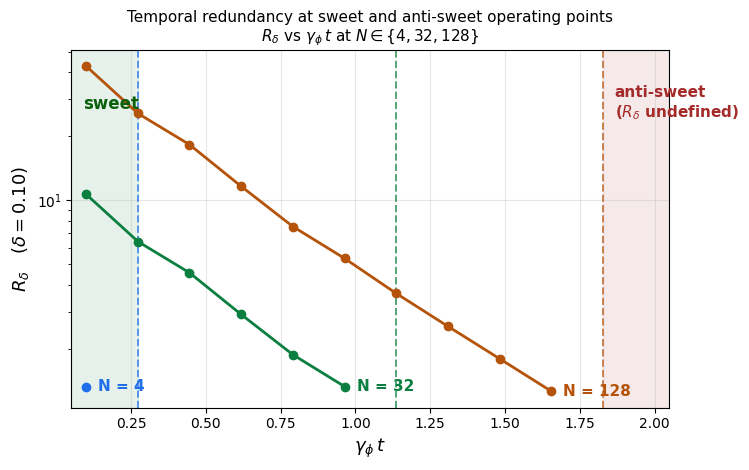

In [7]:
import matplotlib.colors as mcolors
import matplotlib.patches as mpatches

# Type-(b) figure for Harbour View §3: R_delta vs gamma_phi*t at N in {4, 32, 128}.
# Sweet region = where ALL three N's keep R_delta well-defined (gamma_phi*t <= min boundary).
# Anti-sweet region = where NO N keeps R_delta well-defined (gamma_phi*t > max boundary).
# Per-N boundary marked with a dashed vertical line (rising with N per MN v0.3 §8.2).
# Curves identified by direct end-of-curve N labels (no legend; the labels suffice).

b_n_values = [4, 32, 128]
colors_b = {4: '#1f6feb', 32: '#0a7f3f', 128: '#b45309'}

fig_b, ax_b = plt.subplots(figsize=(7.6, 4.8))

# Plot the defined portion of each trace
for n in b_n_values:
    pts = [(row[0], row[2]) for row in cur['grid'][n] if row[2] is not None]
    if pts:
        xs, ys = zip(*pts)
        ax_b.plot(xs, ys, 'o-', color=colors_b[n],
                  linewidth=2.0, markersize=6, zorder=3)

# Per-N undefined-boundary vertical lines
for n in b_n_values:
    b = cur['undefined_boundary'][n]
    if b is not None:
        ax_b.axvline(b, color=colors_b[n], linestyle='--', linewidth=1.4,
                     alpha=0.7, zorder=2)

ax_b.set_xlabel(r'$\gamma_\phi\, t$', fontsize=13)
ax_b.set_ylabel(r'$R_\delta\quad(\delta=0.10)$', fontsize=13)
ax_b.set_yscale('log')
ax_b.grid(True, alpha=0.3, zorder=1)

# Sweet/anti-sweet shading
b_min = min(cur['undefined_boundary'][n] for n in b_n_values)
b_max = max(cur['undefined_boundary'][n] for n in b_n_values)
xlim_l, xlim_r = 0.05, 2.05
ax_b.set_xlim(xlim_l, xlim_r)
ylim = ax_b.get_ylim()

ax_b.axvspan(xlim_l, b_min, alpha=0.10, color='#0a7f3f', zorder=0)
ax_b.axvspan(b_max, xlim_r, alpha=0.10, color='#a52a2a', zorder=0)

# Sweet / anti-sweet region annotations
y_anno = 10 ** (np.log10(ylim[0]) + 0.85 * (np.log10(ylim[1]) - np.log10(ylim[0])))
ax_b.text(xlim_l + 0.04, y_anno, 'sweet',
          color='#0a5f0a', fontsize=12, fontweight='bold', ha='left', va='center')
ax_b.text(b_max + 0.04, y_anno, 'anti-sweet\n($R_\\delta$ undefined)',
          color='#a52a2a', fontsize=11, fontweight='bold', ha='left', va='center')

# Direct end-of-curve N labels (replaces the legend; the dashed boundary lines + matching
# colour visually link each label to its curve and its threshold).
for n in b_n_values:
    pts = [(row[0], row[2]) for row in cur['grid'][n] if row[2] is not None]
    if pts:
        last_x, last_y = pts[-1]
        ax_b.text(last_x + 0.04, last_y, f'N = {n}', color=colors_b[n],
                  fontsize=11, fontweight='bold', ha='left', va='center', zorder=4)

ax_b.set_title('Temporal redundancy at sweet and anti-sweet operating points\n'
               r'$R_\delta$ vs $\gamma_\phi\,t$ at $N \in \{4, 32, 128\}$',
               fontsize=11)
plt.tight_layout()

import pathlib
out_b = pathlib.Path('../../views/figures/figure-03-redundancy-functional-snr.svg')
out_b.parent.mkdir(parents=True, exist_ok=True)
fig_b.savefig(out_b, format='svg', bbox_inches='tight')
print(f'Wrote {out_b.resolve()}')
plt.show()


### 6.2 Type-(c) figure for §4 — the full landscape

The §4 figure situates the §3 type-(b) slices (`N = 4, 32, 128`) in the full `R_delta(N, gamma_phi*t)` landscape. Per Q10b (v0.5 closure: type-(c) sweeps displaying operating points must demarcate anti-sweet), the region above the undefined-boundary curve is shaded as anti-sweet.

<>:68: SyntaxWarning: invalid escape sequence '\d'
<>:68: SyntaxWarning: invalid escape sequence '\d'
/var/folders/xd/psd7xwfj1ndbq3w_vp6rlghw0000gn/T/ipykernel_79450/990689783.py:68: SyntaxWarning: invalid escape sequence '\d'
  'sweet region (well-defined $R_\delta$, colour-mapped) vs anti-sweet region (undefined, shaded)',


Wrote /Users/uwarring/Documents/GitHub/temporal-micro-consensus/views/figures/figure-04-redundancy-landscape.svg


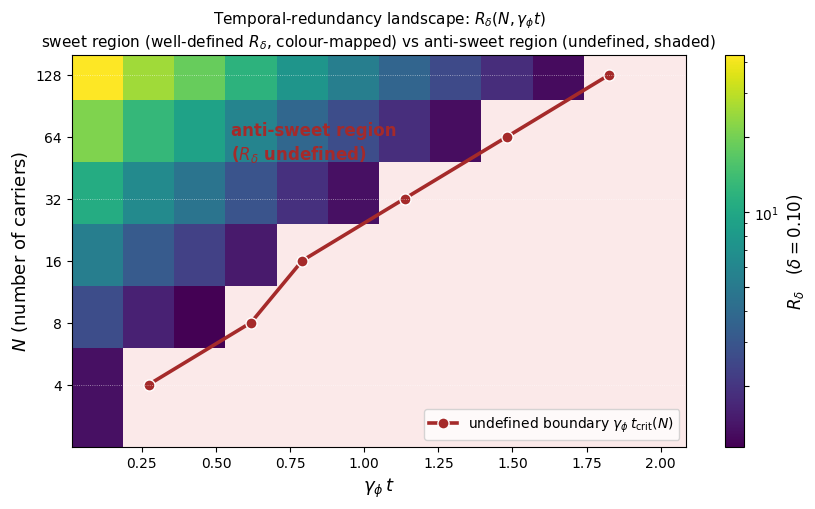

In [8]:
# Type-(c) figure for Harbour View §4: full R_delta(N, gamma_phi*t) landscape with
# undefined-boundary curve (rising with N) and anti-sweet region demarcated per Q10b.
# Same grid as the committed JSON: N in [4, 8, 16, 32, 64, 128], t in linspace(0.1, 2.0, 12).

import matplotlib.colors as mcolors
from matplotlib.ticker import LogLocator
n_grid_c = [4, 8, 16, 32, 64, 128]
t_grid_c = sorted({row[0] for row in cur['grid'][n_grid_c[0]]})

# Build R_delta matrix (rows = N, cols = t); NaN where undefined
R_mat = np.full((len(n_grid_c), len(t_grid_c)), np.nan)
for i, n in enumerate(n_grid_c):
    for row in cur['grid'][n]:
        t = row[0]
        R = row[2]
        if R is not None and t in t_grid_c:
            j = t_grid_c.index(t)
            R_mat[i, j] = R

fig_c, ax_c = plt.subplots(figsize=(8.6, 5.2))

# Heatmap on log color scale; NaN cells get the anti-sweet background colour
cmap_c = plt.get_cmap('viridis').copy()
cmap_c.set_bad(color='#fbe9e9')  # very light red — anti-sweet visual cue
vmin = np.nanmin(R_mat[R_mat > 0])
vmax = np.nanmax(R_mat)
norm_c = mcolors.LogNorm(vmin=vmin, vmax=vmax)
im_c = ax_c.pcolormesh(t_grid_c, n_grid_c, R_mat,
                       cmap=cmap_c, norm=norm_c, shading='auto')
cbar = plt.colorbar(im_c, ax=ax_c)
cbar.set_label(r'$R_\delta\quad(\delta=0.10)$', fontsize=12)
# Explicit log-spaced ticks (3–5 values) for readability
cbar.locator = LogLocator(base=10.0, subs=[1.0, 2.0, 5.0], numticks=6)
cbar.update_ticks()

# Undefined-boundary curve (rising with N)
b_n_arr = []
b_t_arr = []
for n in n_grid_c:
    b = cur['undefined_boundary'][n]
    if b is not None:
        b_n_arr.append(n)
        b_t_arr.append(b)

ax_c.plot(b_t_arr, b_n_arr, 'o-', color='#a52a2a', linewidth=2.6, markersize=8,
          label=r'undefined boundary $\gamma_\phi\, t_{\rm crit}(N)$',
          markeredgecolor='white', markeredgewidth=1)

# Anti-sweet region annotation — placed *inside* the light-pink anti-sweet shaded area
# (well clear of the colorbar on the right). The pink region is above the boundary curve
# at small N; placing the label at (gamma_phi*t ≈ 0.55, N ≈ 60) puts it squarely inside
# the visible anti-sweet block.
ax_c.text(0.55, 60.0,
          'anti-sweet region\n($R_\\delta$ undefined)',
          color='#a52a2a', fontsize=12, fontweight='bold',
          ha='left', va='center')

# Mark the §3 type-(b) slices for cross-link clarity
for n_slice in [4, 32, 128]:
    ax_c.axhline(n_slice, color='white', linewidth=0.6, alpha=0.6, linestyle=':')

ax_c.set_xlabel(r'$\gamma_\phi\, t$', fontsize=13)
ax_c.set_ylabel(r'$N$ (number of carriers)', fontsize=13)
ax_c.set_yscale('log', base=2)
ax_c.set_yticks(n_grid_c)
ax_c.set_yticklabels([str(n) for n in n_grid_c])
ax_c.set_title('Temporal-redundancy landscape: ' r'$R_\delta(N, \gamma_\phi t)$' '\n'
               'sweet region (well-defined $R_\delta$, colour-mapped) vs anti-sweet region (undefined, shaded)',
               fontsize=11)
ax_c.legend(loc='lower right', frameon=True, fontsize=10)
plt.tight_layout()

out_c = pathlib.Path('../../views/figures/figure-04-redundancy-landscape.svg')
fig_c.savefig(out_c, format='svg', bbox_inches='tight')
print(f'Wrote {out_c.resolve()}')
plt.show()
